In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [2]:
class Layer(nn.Module):
    def __init__(self, activation, units=16):
        super(Layer, self).__init__()
        self.linear = nn.Linear(units, units)
        self.activation = activation()

    def initialize(self, init):
        init(self.linear.weight)

    def forward(self, x):
        return self.activation(self.linear(x))


def model(activation, units, layers):
    return nn.Sequential(
        *[Layer(activation, units) for _ in range(layers)]
    )

In [3]:
activations = [('SIGMOID', nn.Sigmoid), ('TANH', nn.Tanh), ('RELU', nn.ReLU)]

layers = 4
units = 256
x = torch.randn(units)

def experiment(init=None):
    with torch.no_grad():
        _, axes = plt.subplots(len(activations), layers + 1, figsize=(30, 15))


        for k, (name, activation) in enumerate(activations):
            net = model(activation, units, layers)

            if init:
                for layer in net:
                    layer.initialize(init)

            prop = [x]

            for layer in net:
                prop.append(layer.forward(prop[-1]))

            for i, p in enumerate(prop):
                subplot = axes[k, i]
                subplot.hist(p.view(-1).detach().numpy(), bins=50)
                subplot.title.set_text(f"{name} Layer {i} output\nmean: {p.mean():.2f}, std: {p.std():.2f}")
                three_std = p.std() * 3

                subplot.set_xlim(torch.floor(p.mean() - three_std), torch.ceil(p.mean() + three_std))


    plt.show()


## Small weights

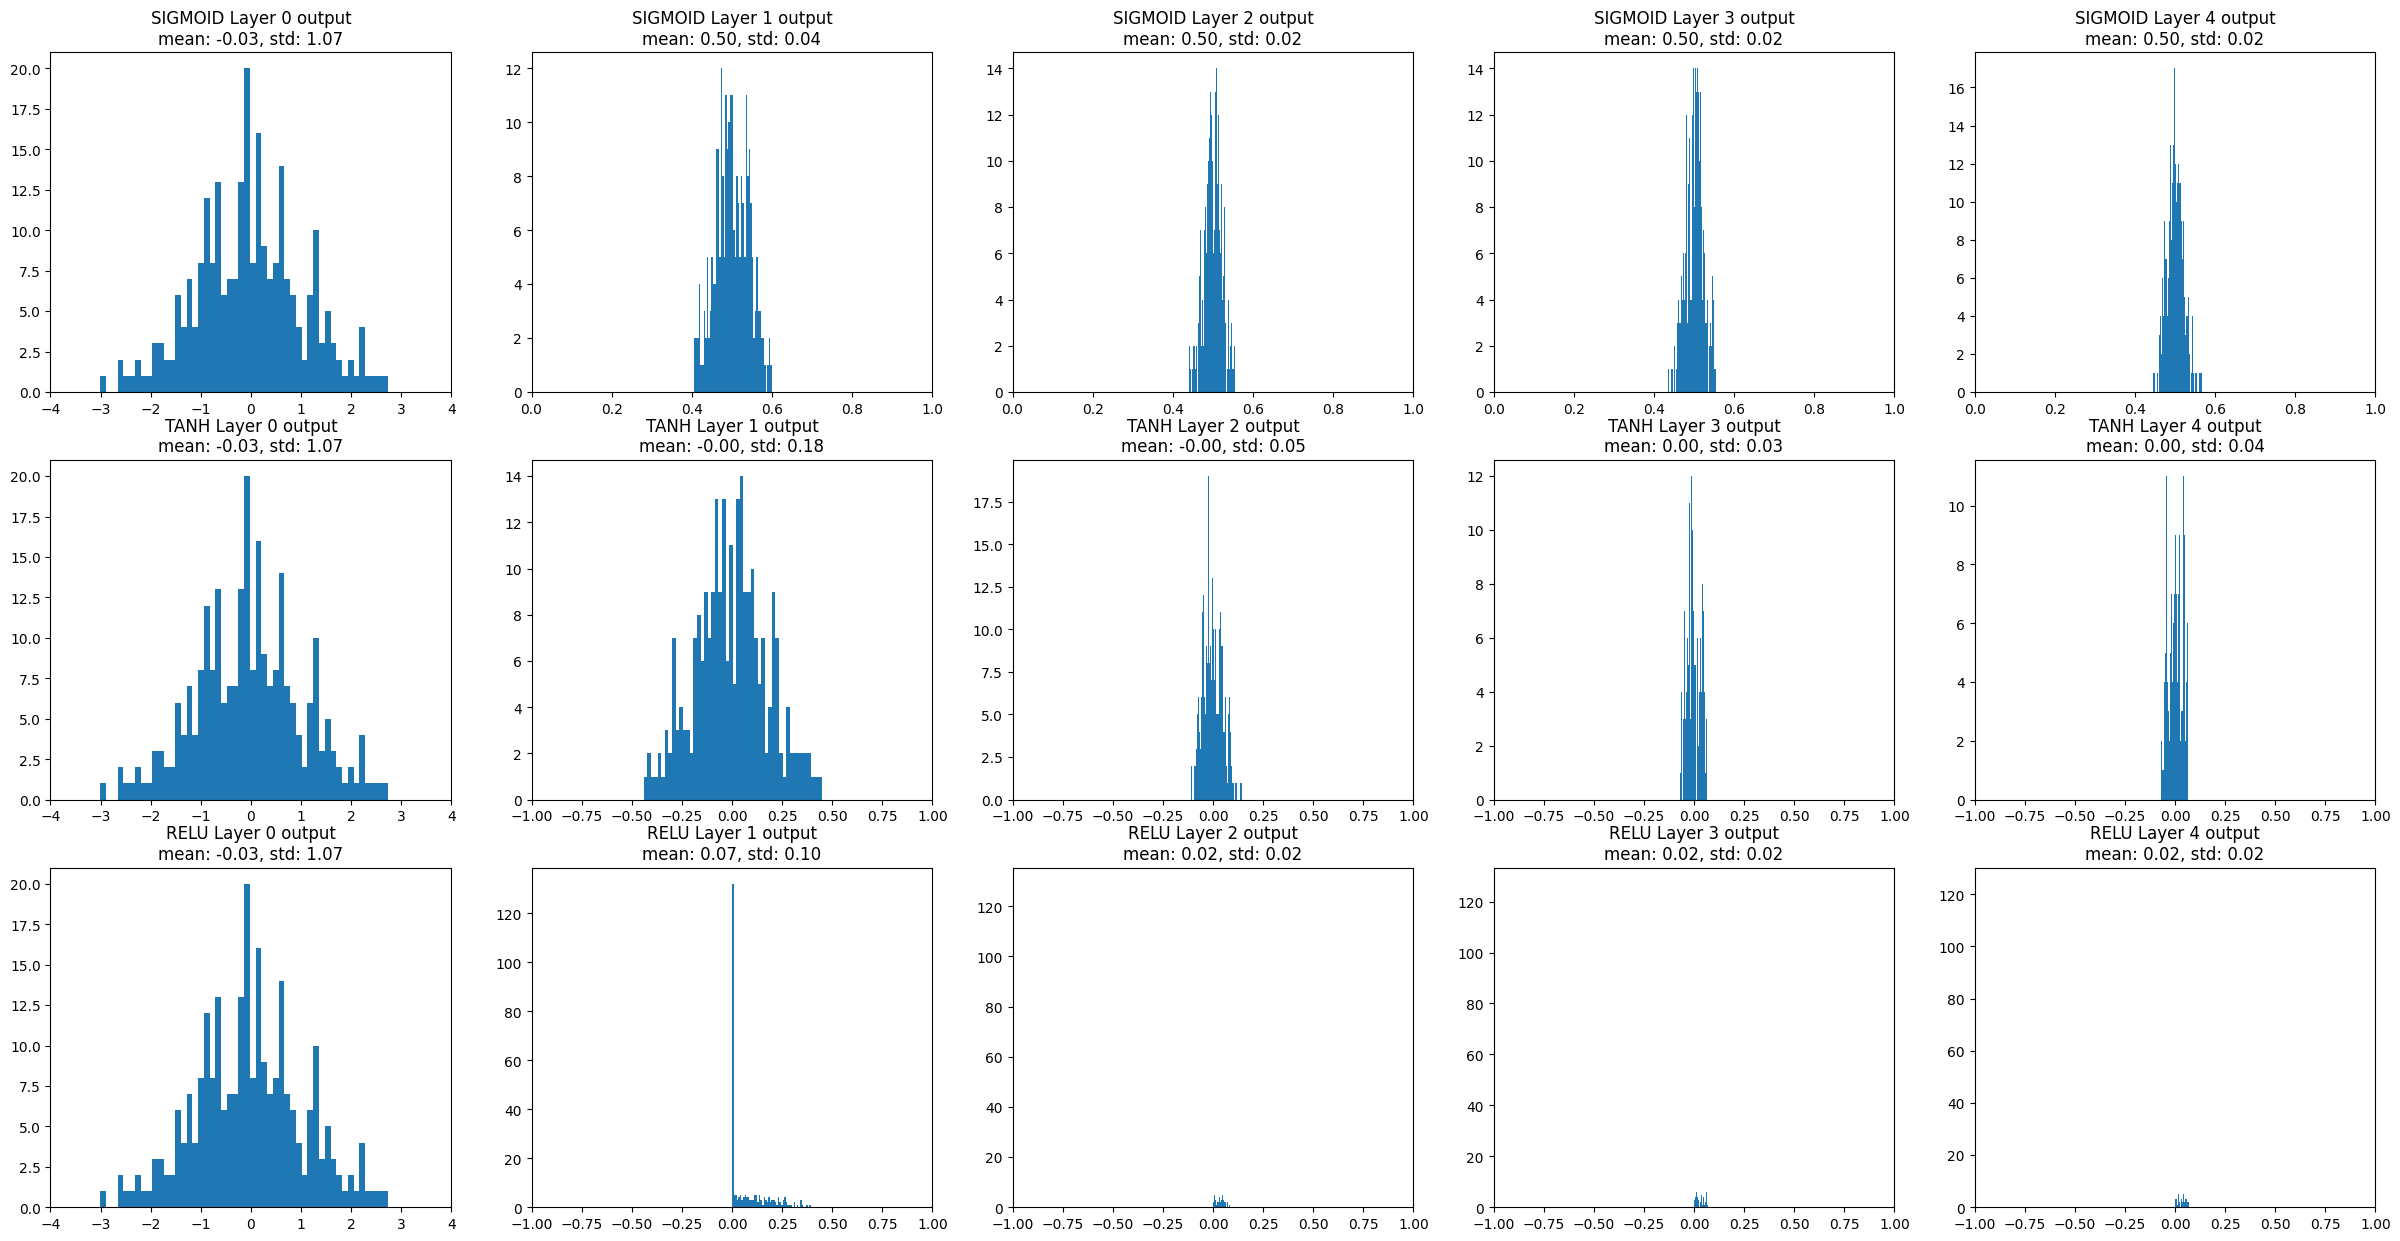

In [4]:
experiment(init= lambda x: nn.init.normal_(x, 0.0, 0.01))

## Large weights

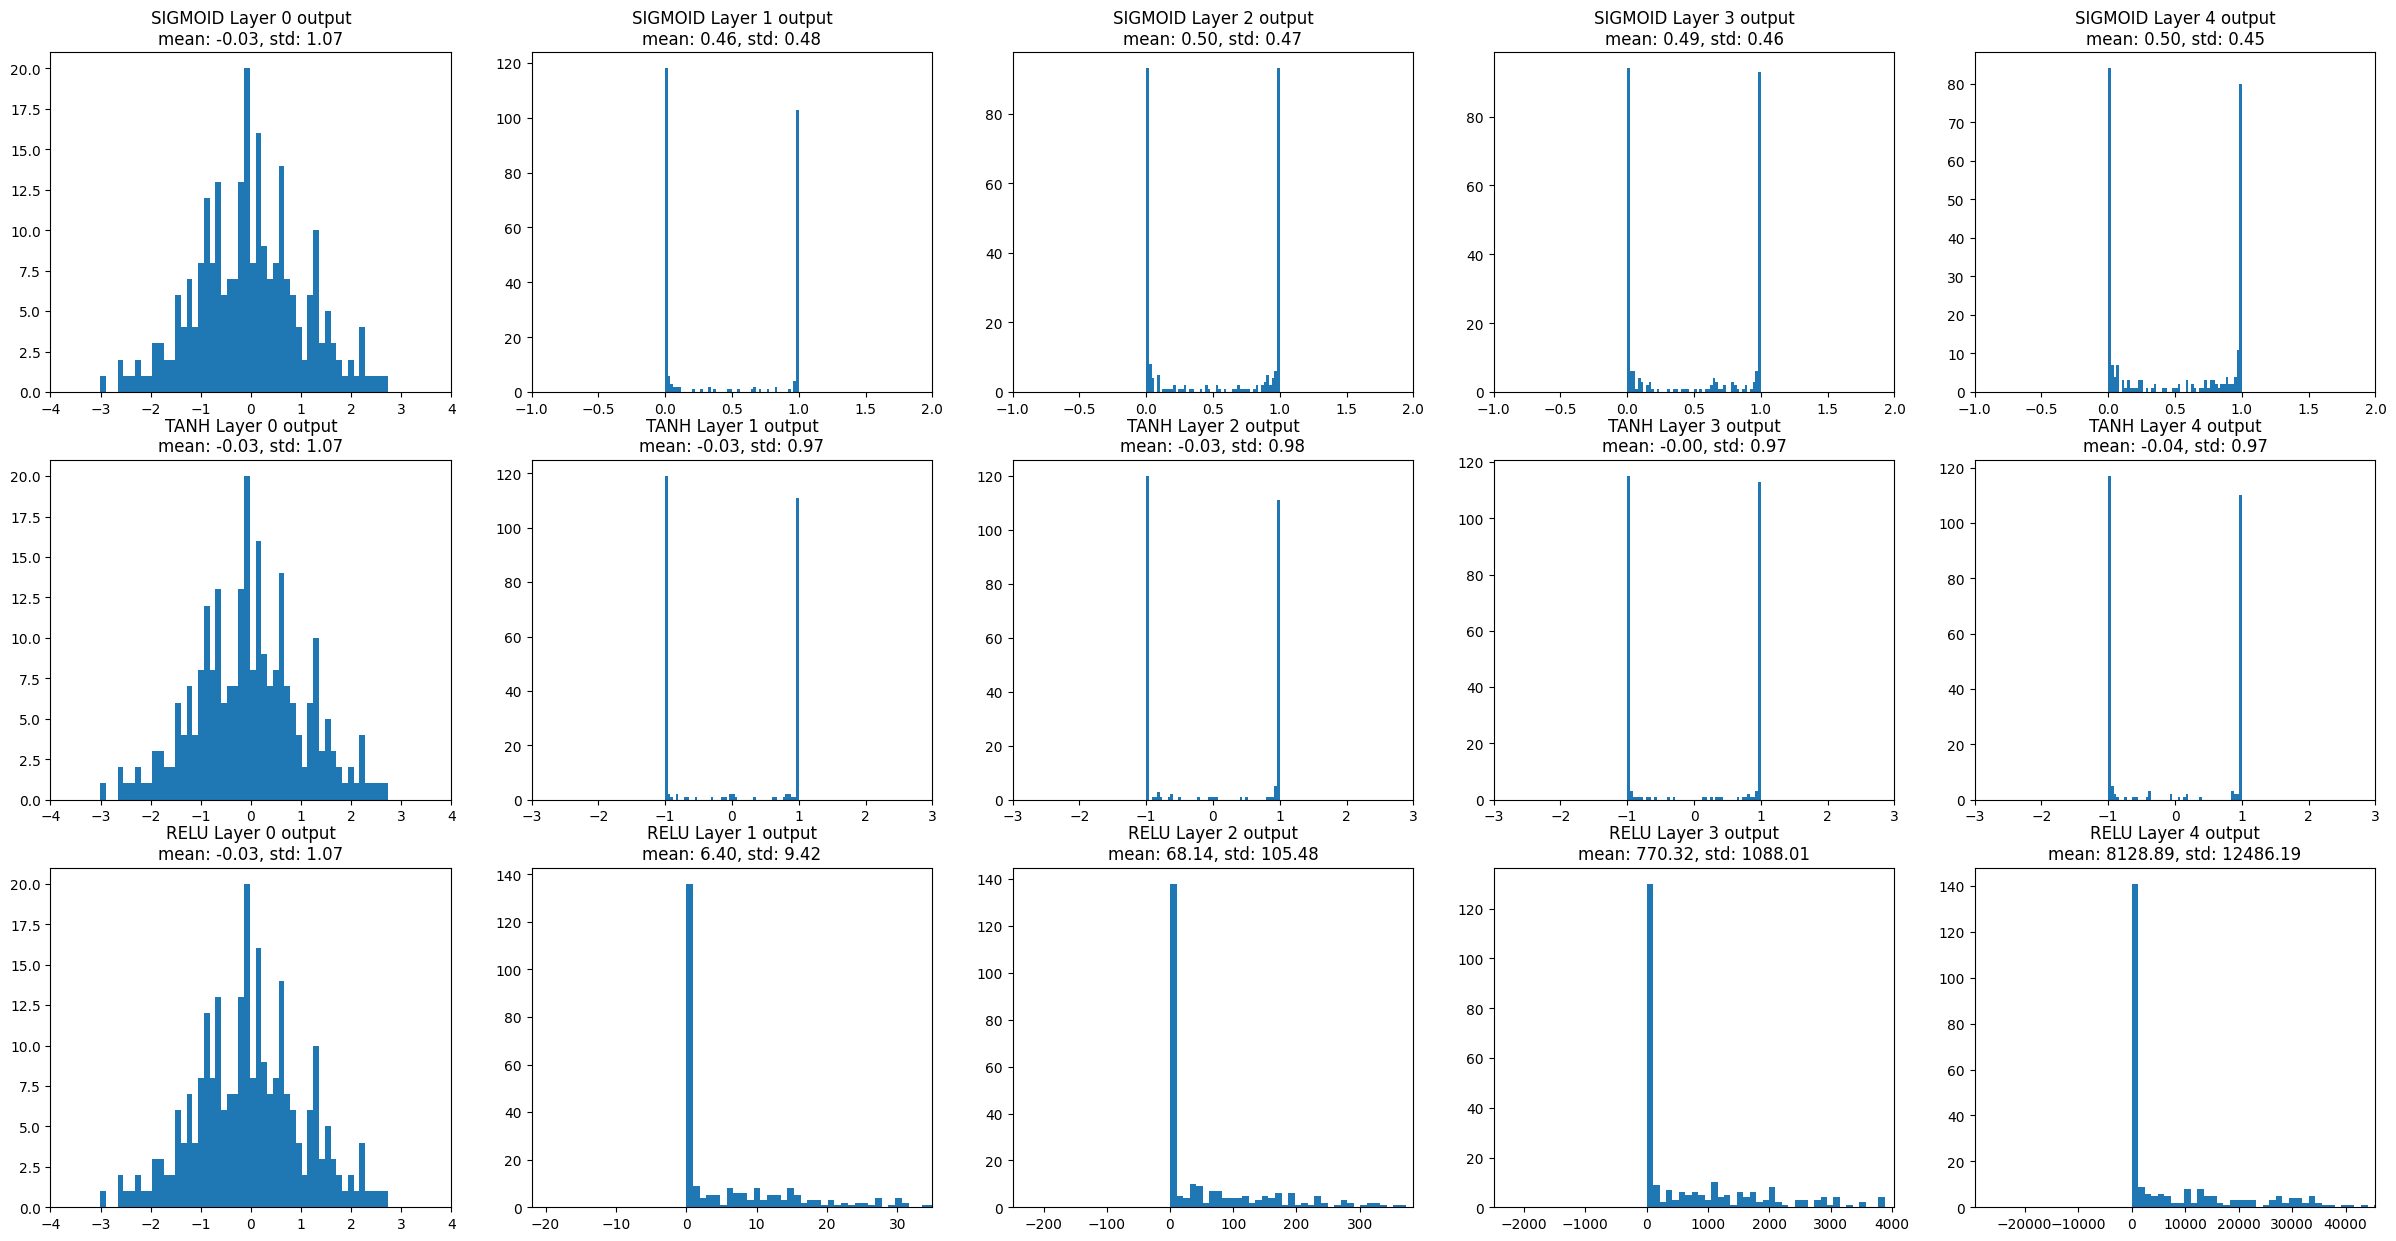

In [5]:
experiment(init= lambda x: nn.init.normal_(x, 0, 1))

## Keeping activation variance = 1

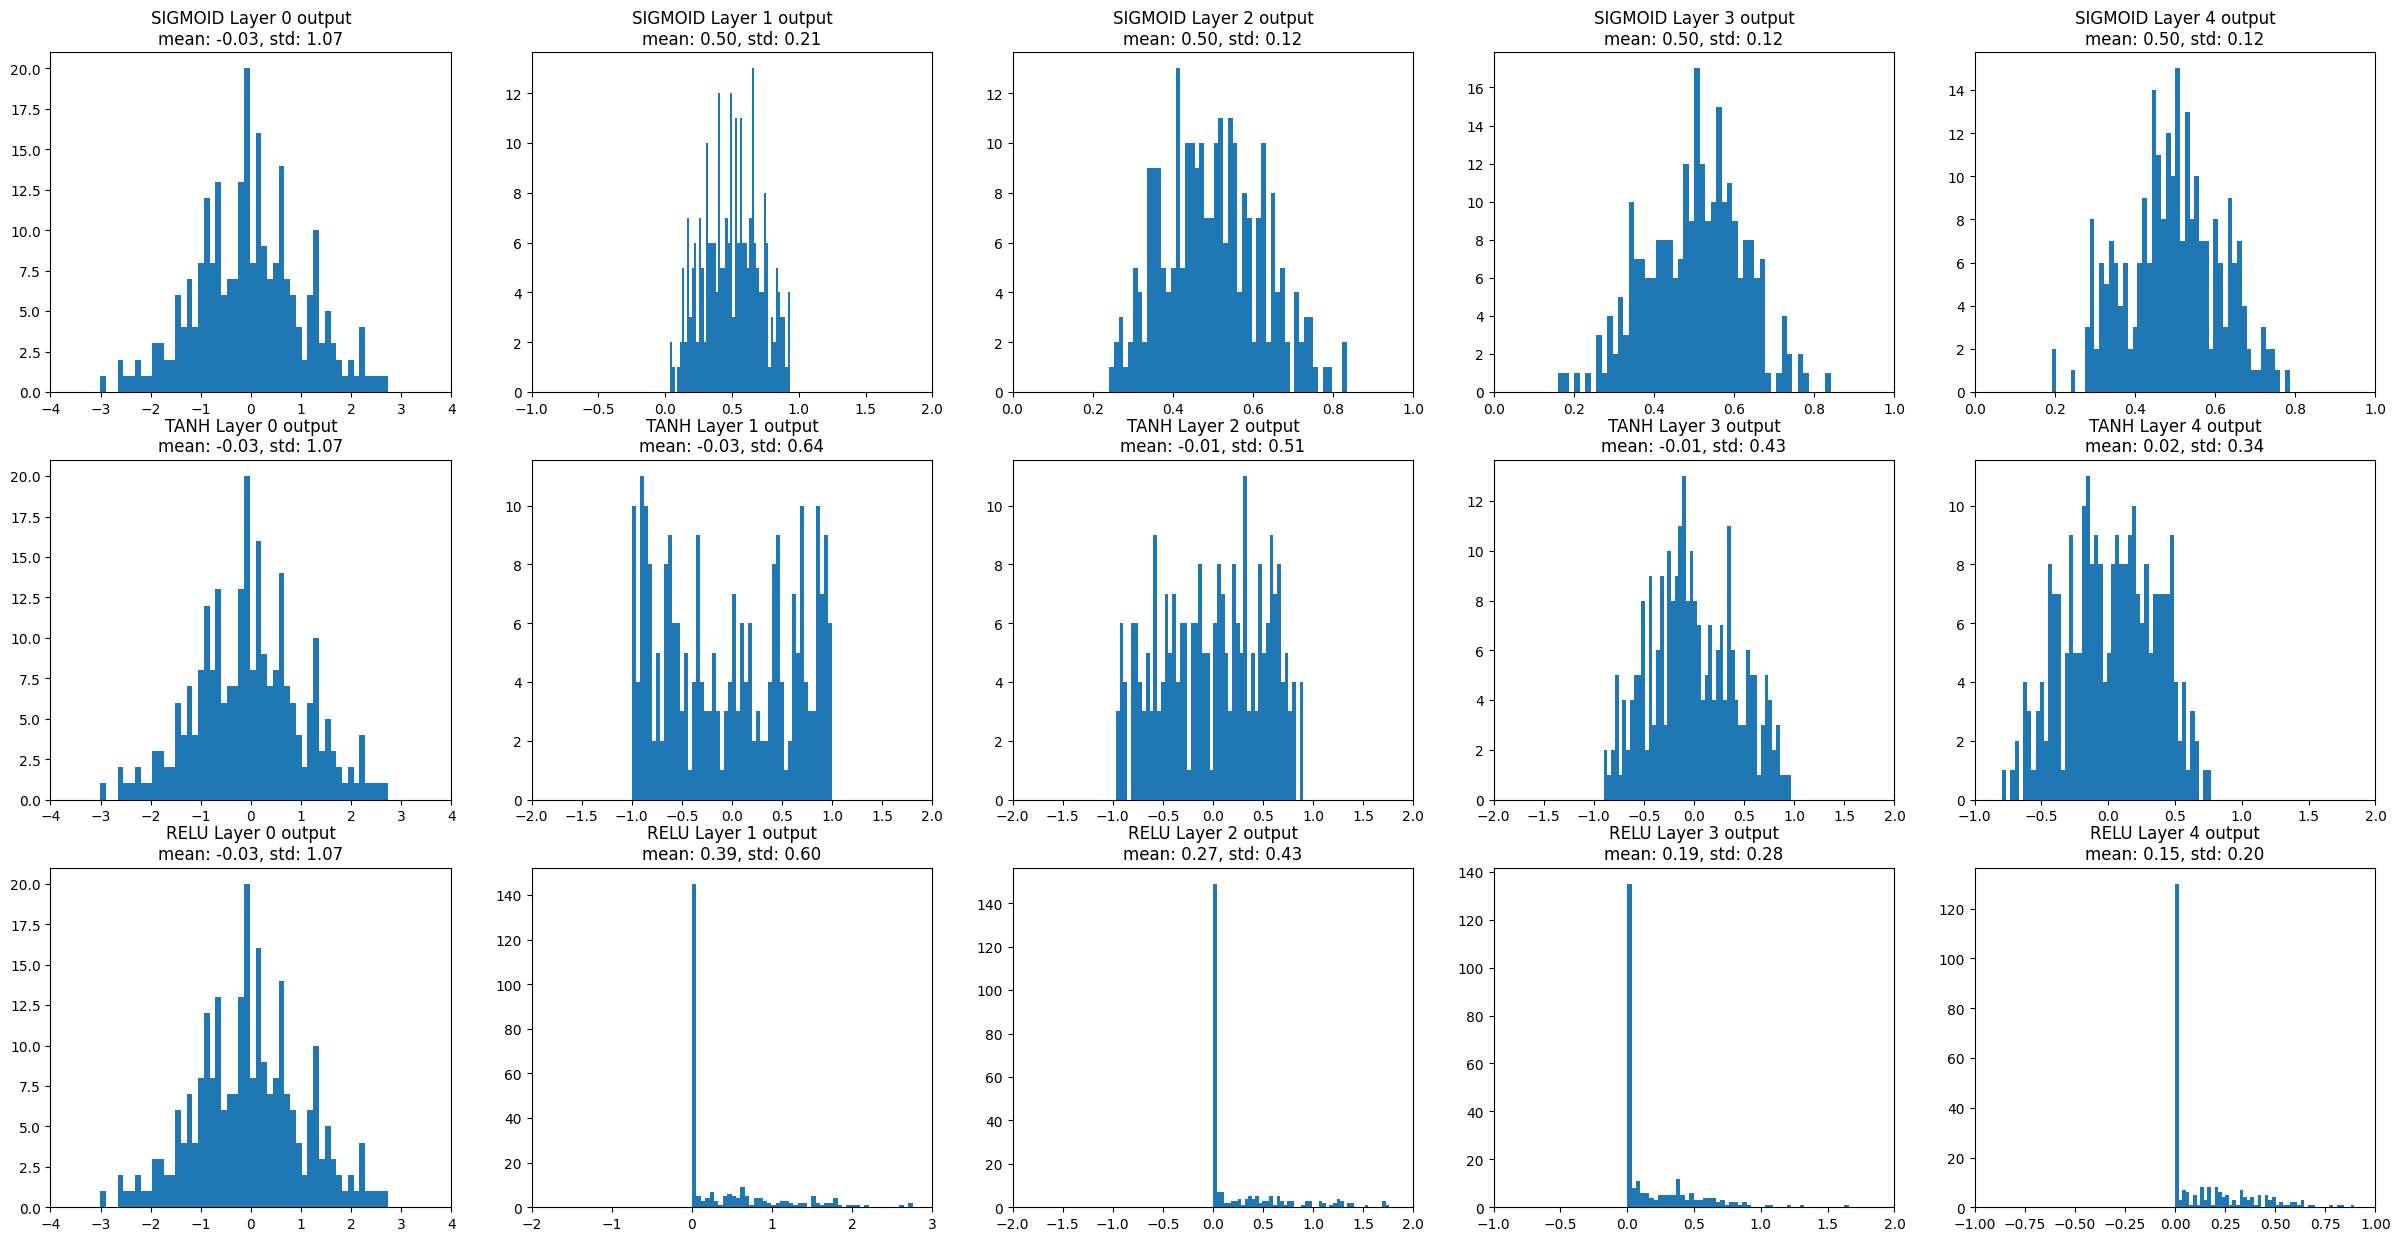

In [6]:
sd = 1.0/(units ** 0.5)

experiment(init= lambda x: nn.init.normal_(x, 0, sd))

## RELU adjustment

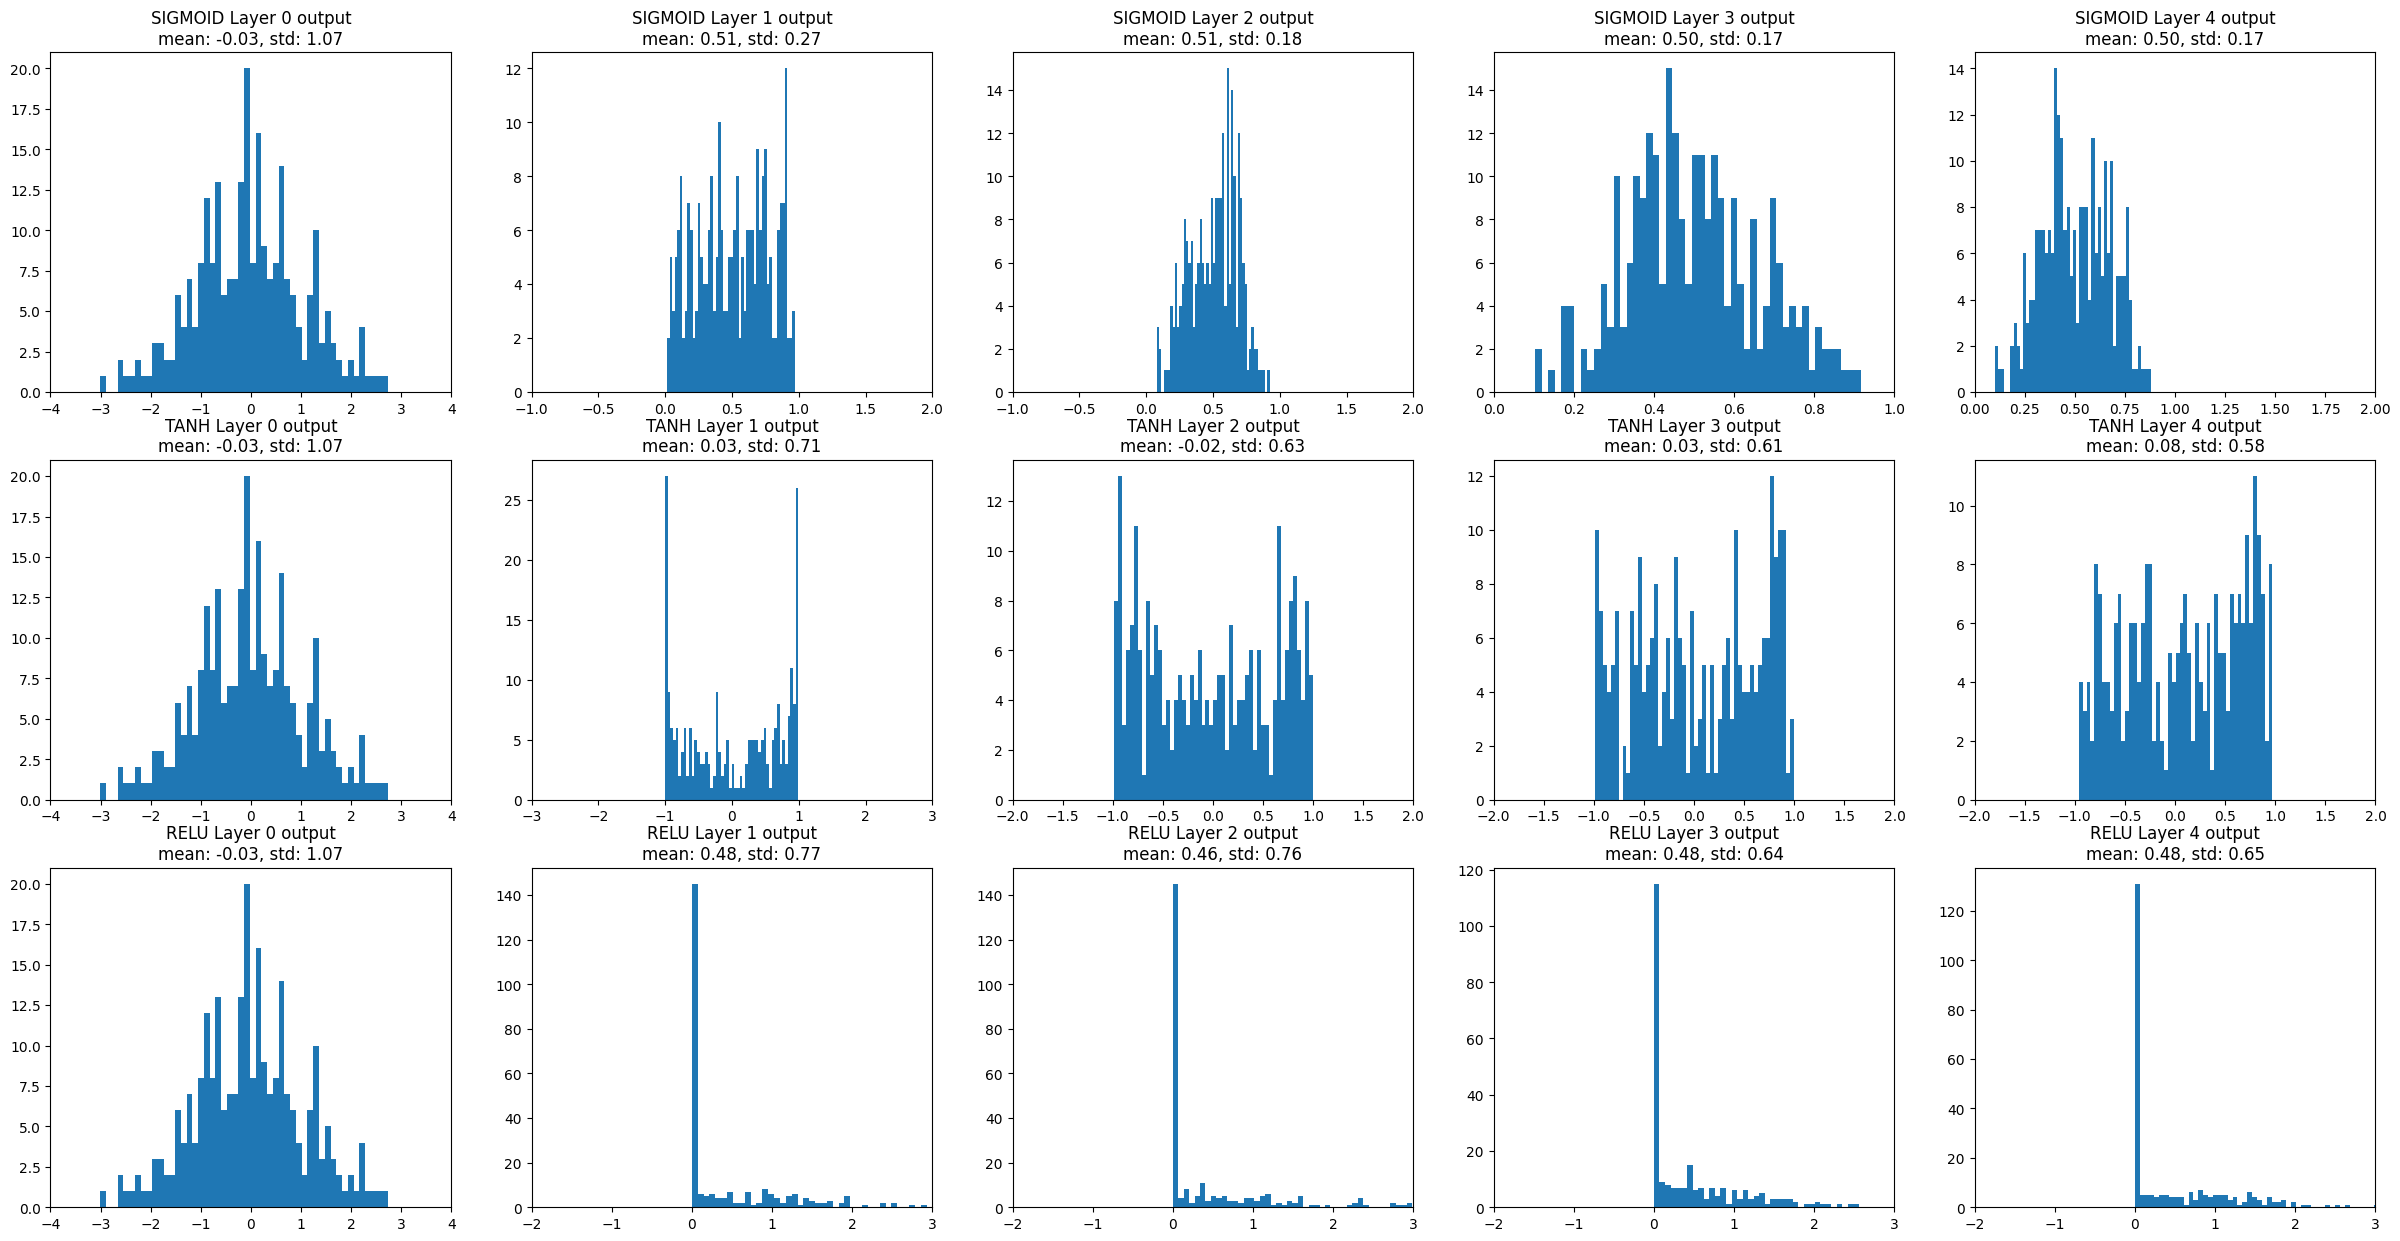

In [7]:
sd = 1.0/((0.5 * units) ** 0.5)

experiment(init= lambda x: nn.init.normal_(x, 0, sd))

## Using uniform distribution instead


Intuitively it makes sense to  use uniform distribution instead of normal distribution to introduce some diversity to the initial weights and neurons. Still the subsequent layers seem to lack diversity on activations.


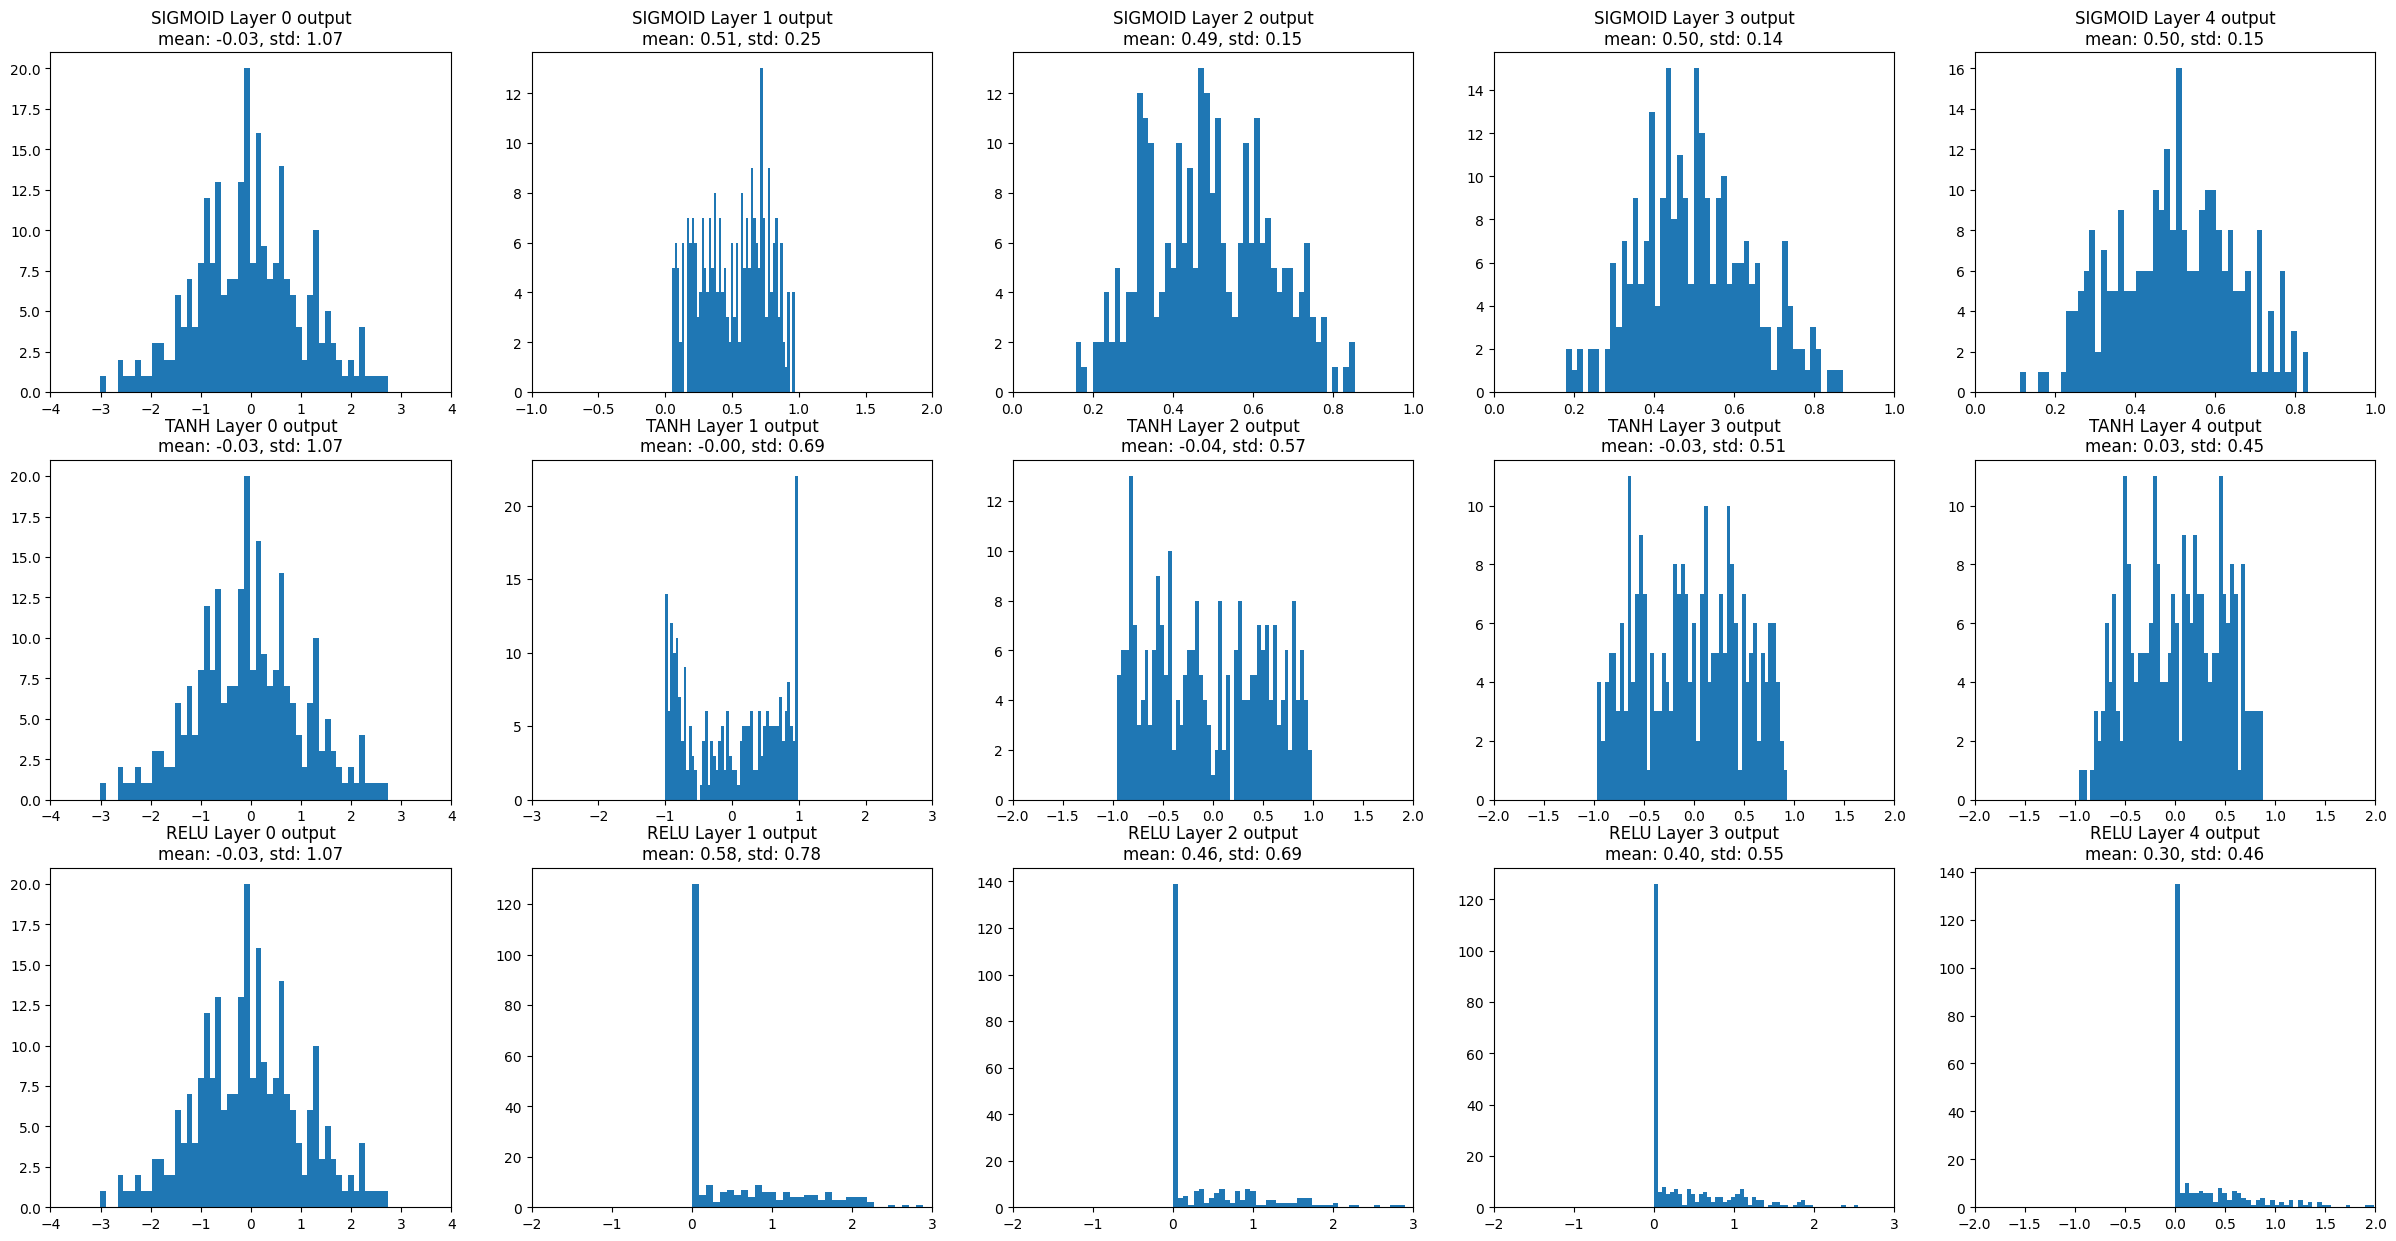

In [8]:
sd = 2.0/(units ** 0.5)

experiment(init= lambda x: nn.init.uniform_(x, -sd, sd))

## Xavier scaling

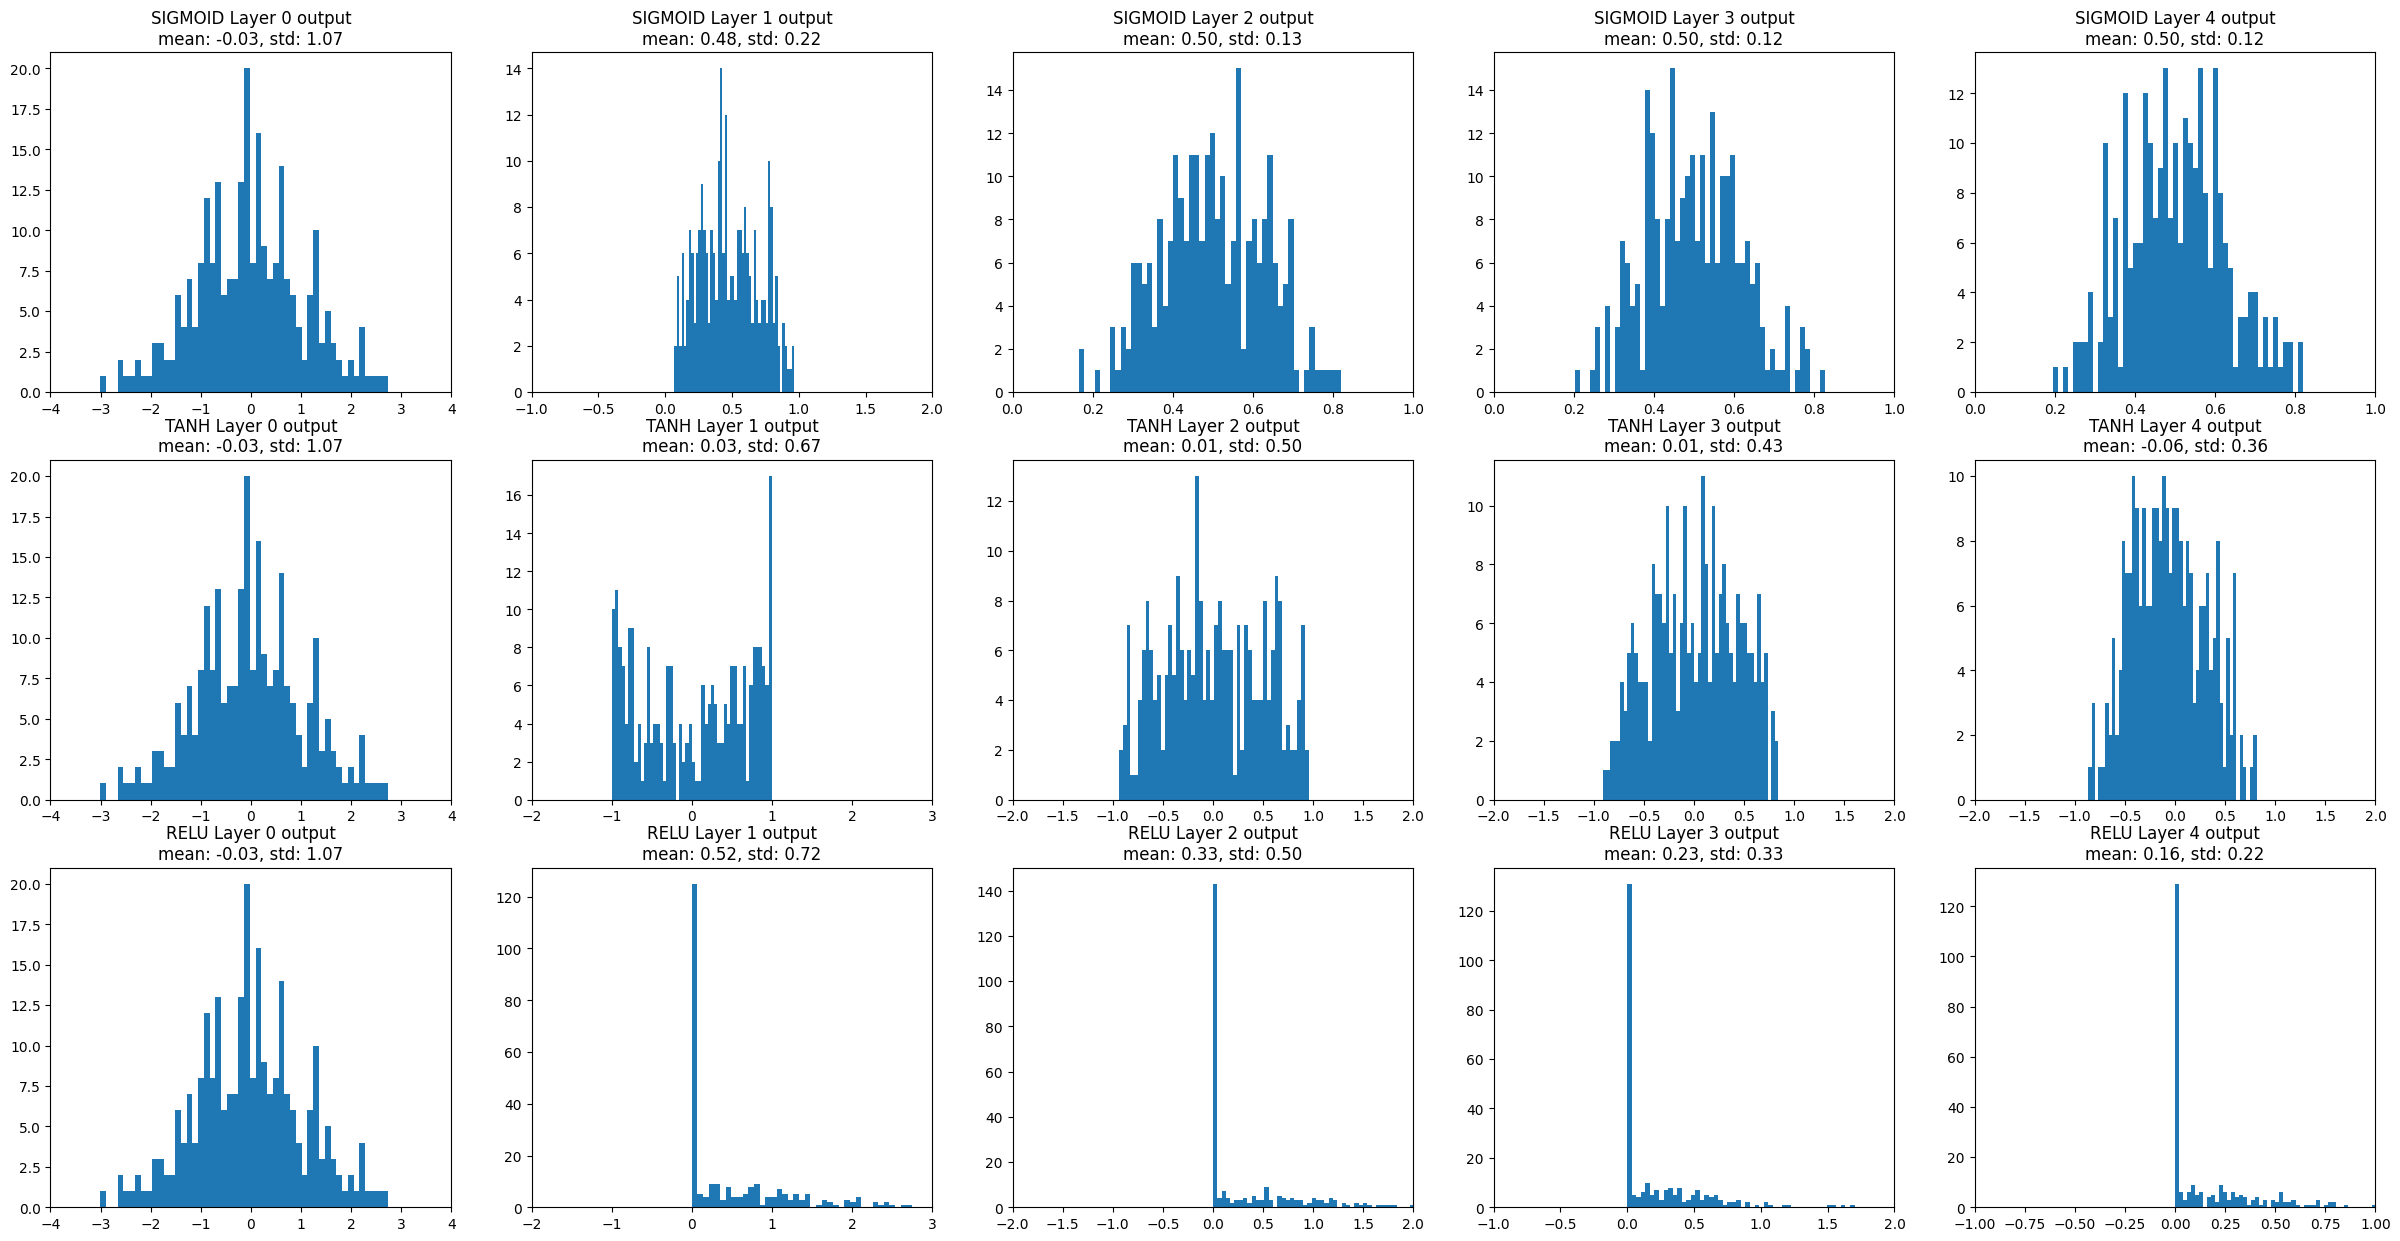

In [9]:
xavier_scale = (6.0 / (units + units)) ** 0.5
experiment(init= lambda x: nn.init.uniform_(x, -xavier_scale, xavier_scale))